# 1.3 Processing Times
**Responsible:** _Thomas P. Hartel_

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pm4py
from datetime import datetime, timedelta

sns.set(style="whitegrid")

In [2]:
LOG1_PATH = "../data/logdata.xes"
LOG2_PATH = "../data/generated_log.xes"

CASE_COL = "case:concept:name"
ACTIVITY_COL = "concept:name"
TIME_COL = "time:timestamp"

In [3]:
def load_log(path):
    df = pm4py.read_xes(path, variant="r4pm")

    df[TIME_COL] = pd.to_datetime(df[TIME_COL])

    df = df.sort_values([CASE_COL, TIME_COL])

    return df

log1 = load_log(LOG1_PATH)
log2 = load_log(LOG2_PATH)

In [5]:
def format_data(log: pd.DataFrame):
    # Sort events chronologisch
    log = log.sort_values(["case:concept:name", "concept:name", "time:timestamp"])
    event_times = []
    
    # Gruppieren nach Case und Aktivität
    for (case, activity), event_data in log.groupby(["case:concept:name", "concept:name"]):

        first_date = datetime(2000,1,1)
        applicationType = None
        requestedAmount = None

        event_data = event_data.sort_values("time:timestamp")
        active_start = None
        total_active_time = timedelta(0)
        activity_waiting = None
        total_waiting_time = timedelta(0)
        for _, log_entry in event_data.iterrows():
            event = log_entry["lifecycle:transition"]
            if event == "start":
                active_start = log_entry["time:timestamp"]
                total_active_time = timedelta(0)
                first_date = log_entry["time:timestamp"]
                applicationType = log_entry["case:ApplicationType"]
                requestedAmount = log_entry["case:RequestedAmount"]
            elif event == "resume":
                active_start = log_entry["time:timestamp"]

                total_waiting_time = activity_waiting - log_entry["time:timestamp"]
            elif event == "suspend":
                if active_start is not None:
                    total_active_time += (log_entry["time:timestamp"] - active_start)
                    active_start = None

                    activity_waiting = log_entry["time:timestamp"]
            elif event == "complete":
                if active_start is not None:
                    total_active_time += (log_entry["time:timestamp"] - active_start)
                    active_start = None
                    #resets activity so that if it reoccurs another entry is written
                event_times.append({
                    "case:concept:name": case,
                    "concept:name": activity,
                    "processing_time": total_active_time.seconds,
                    "waiting_time": total_waiting_time.seconds,
                    "org:resource": log_entry["org:resource"],
                    "case:RequestedAmount": requestedAmount,
                    "case:ApplicationType": applicationType,
                    "HourOfDay": first_date.hour,
                    "Weekday": first_date.weekday()
                })
    return pd.DataFrame.from_records(event_times)

In [6]:
df1 = format_data(log1)
df2 = format_data(log2)

In [7]:
summary = pd.DataFrame({
    "Log 1": {
        "Mean Processing": df1["processing_time"].mean(),
        "Median Processing": df1["processing_time"].median(),
        "Mean Waiting": df1["waiting_time"].mean(),
        "Median Waiting": df1["waiting_time"].median(),
    },
    "Log 2": {
        "Mean Processing": df2["processing_time"].mean(),
        "Median Processing": df2["processing_time"].median(),
        "Mean Waiting": df2["waiting_time"].mean(),
        "Median Waiting": df2["waiting_time"].median(),
    }
})

print(summary)

                         Log 1  Log 2
Mean Processing      87.099588    0.0
Median Processing     0.000000    0.0
Mean Waiting       3074.253998    0.0
Median Waiting        0.000000    0.0


In [8]:
comparison = (
    df1.groupby("concept:name")
       .agg(
           processing_log1=("processing_time", "mean"),
           waiting_log1=("waiting_time", "mean")
       )
       .merge(
           df2.groupby("concept:name")
              .agg(
                  processing_log2=("processing_time", "mean"),
                  waiting_log2=("waiting_time", "mean")
              ),
           left_index=True,
           right_index=True,
           how="outer"
       )
)

comparison["Processing Difference"] = (
    comparison["processing_log2"] - comparison["processing_log1"]
)

comparison["Waiting Difference"] = (
    comparison["waiting_log2"] - comparison["waiting_log1"]
)

comparison

,processing_log1,waiting_log1,processing_log2,waiting_log2,Processing Difference,Waiting Difference
concept:name,,,,,,
A_Accepted,0.000000,0.000000,NaN,NaN,NaN,NaN
A_Cancelled,0.000000,0.000000,NaN,NaN,NaN,NaN
A_Complete,0.000000,0.000000,NaN,NaN,NaN,NaN
A_Concept,0.000000,0.000000,NaN,NaN,NaN,NaN
A_Create Application,0.000000,0.000000,0.0,0.0,0.0,0.0
A_Denied,0.000000,0.000000,NaN,NaN,NaN,NaN
A_Incomplete,0.000000,0.000000,NaN,NaN,NaN,NaN
A_Pending,0.000000,0.000000,NaN,NaN,NaN,NaN
A_Submitted,0.000000,0.000000,NaN,NaN,NaN,NaN


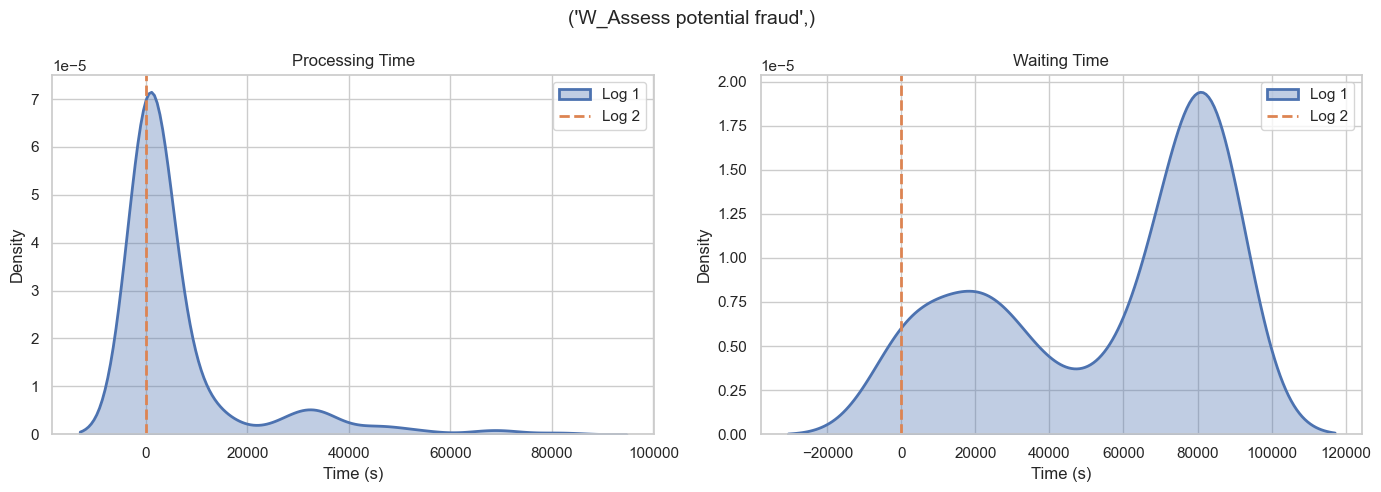

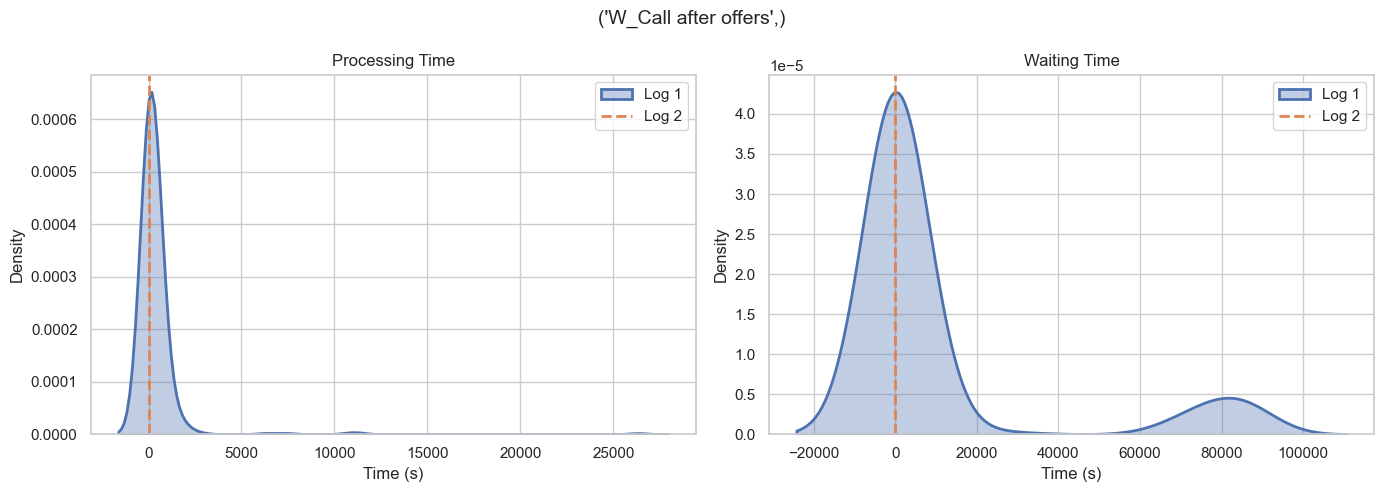

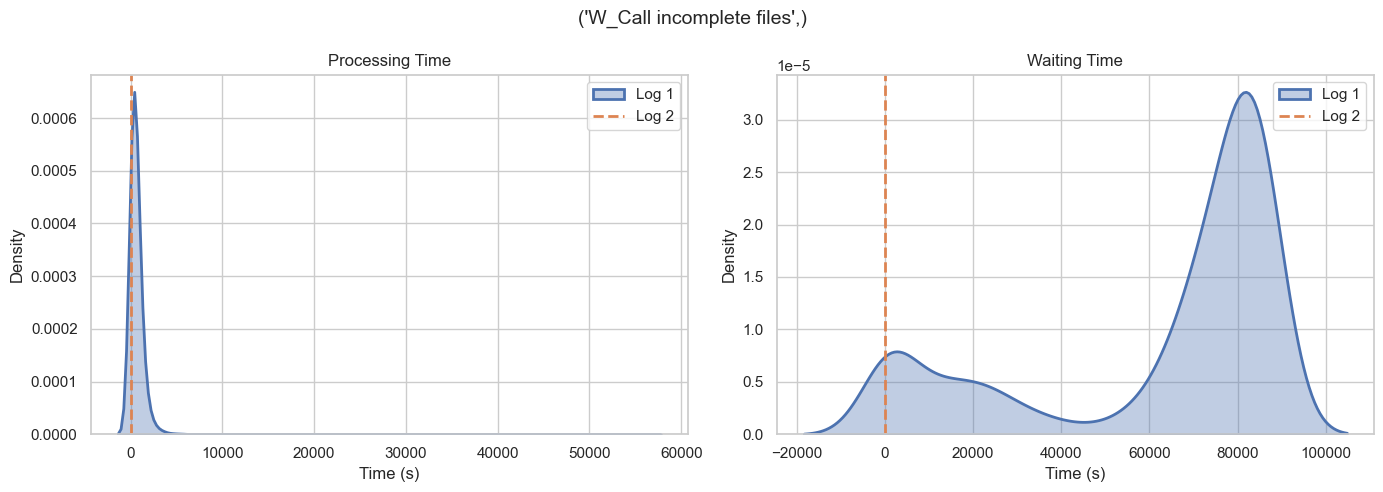

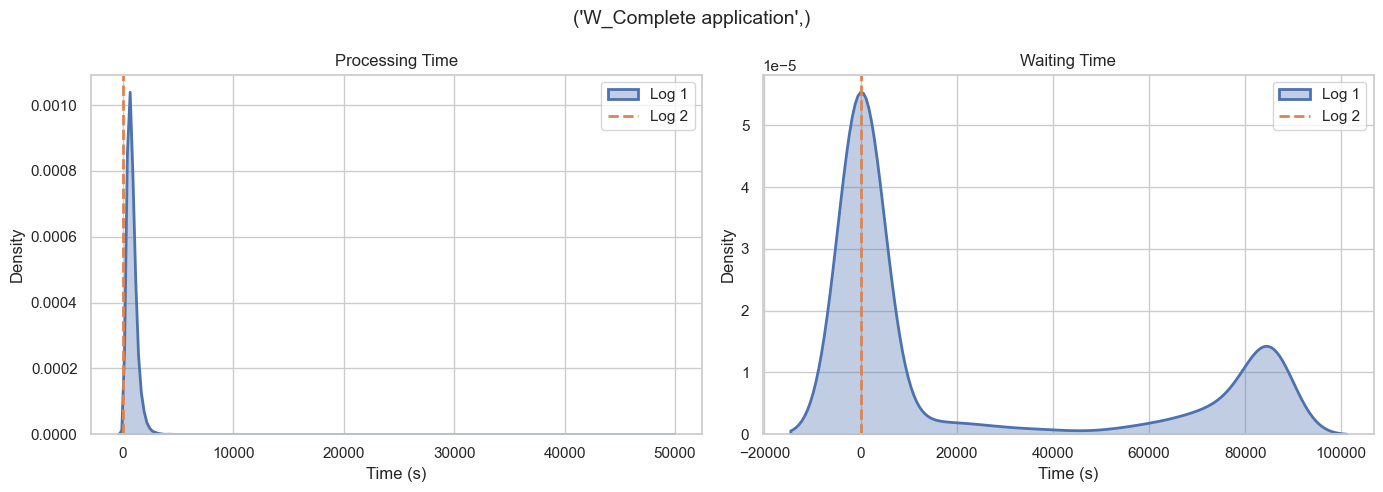

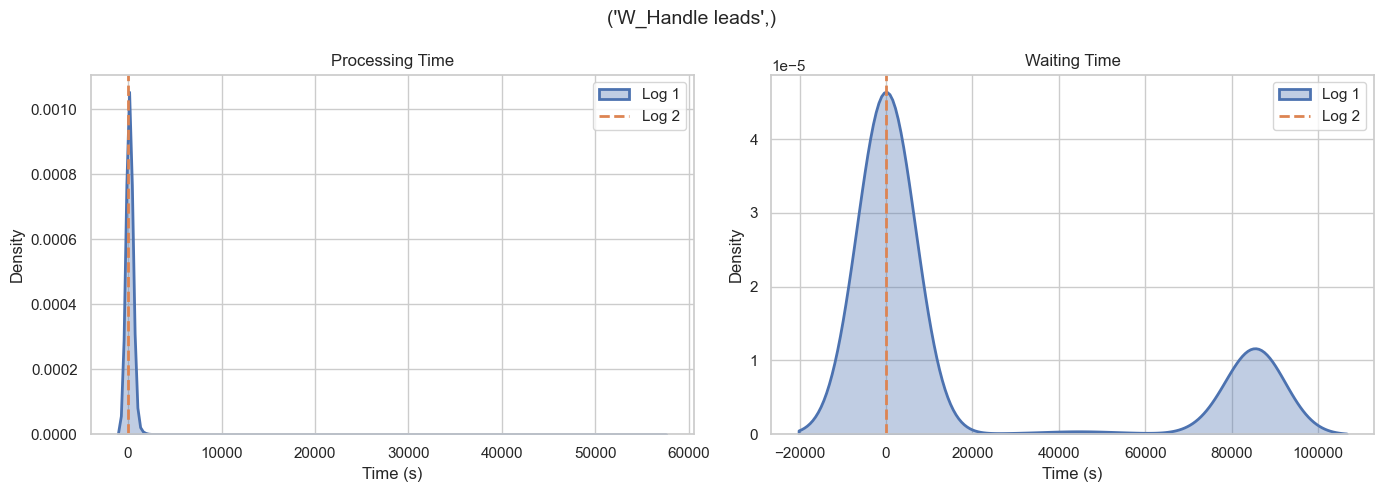

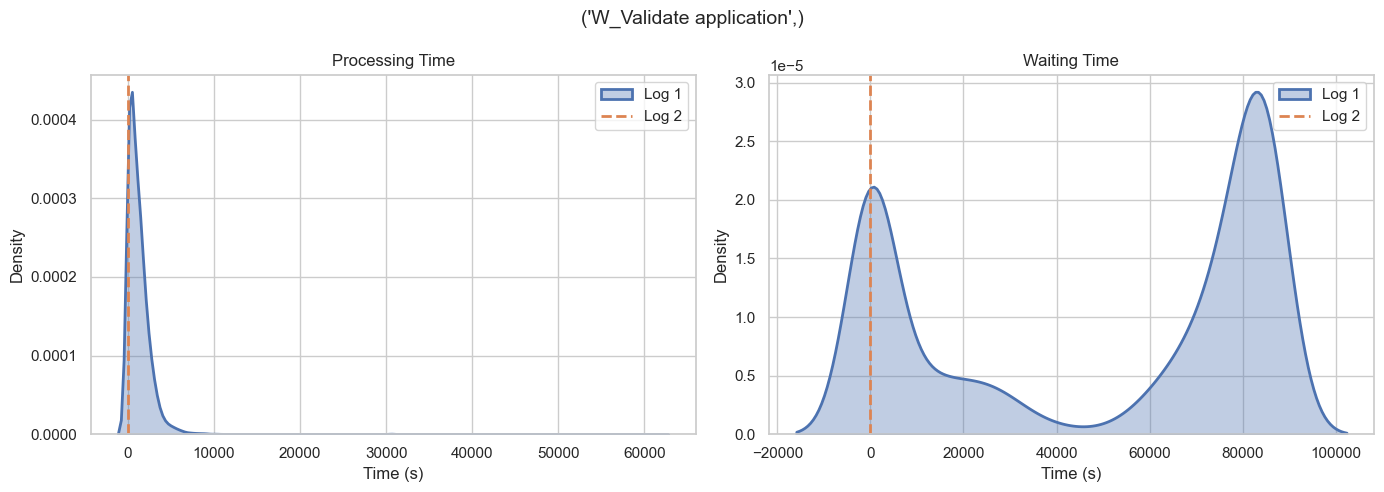

In [9]:
groups1 = {k: g for k, g in df1.groupby(["concept:name"])}
groups2 = {k: g for k, g in df2.groupby(["concept:name"])}

keys = sorted(set(groups1.keys()).union(groups2.keys()))

for activity in keys:

    g1 = groups1.get((activity), pd.DataFrame())
    g2 = groups2.get((activity), pd.DataFrame())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{activity}", fontsize=14)

    plotted = False

    for ax, metric, title in zip(axes,
        ["processing_time", "waiting_time"],
        ["Processing Time", "Waiting Time"],):

        x1 = g1.get(metric, pd.Series(dtype=float)).dropna()
        x2 = g2.get(metric, pd.Series(dtype=float)).dropna()

        if len(x1) == 0 or np.all(x1 == 0):
            ax.set_visible(False)
            continue

        if len(x2) == 0:
            x2 = pd.Series([0.0])

        if x1.nunique() > 1:
            sns.kdeplot(
                x=x1,
                ax=ax,
                fill=True,
                alpha=0.35,
                linewidth=2,
                label="Log 1",
            )
        else:
            ax.axvline(
                x1.iloc[0],
                color="C0",
                linewidth=2,
                linestyle="--",
                label="Log 1",
            )

        if x2.nunique() > 1:
            sns.kdeplot(
                x=x2,
                ax=ax,
                fill=True,
                alpha=0.35,
                linewidth=2,
                label="Log 2",
            )
        else:
            ax.axvline(
                x2.iloc[0],
                color="C1",
                linewidth=2,
                linestyle="--",
                label="Log 2",
            )

        ax.set_title(title)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Density")
        ax.legend()

        plotted = True

    if plotted:
        plt.tight_layout()
        plt.show()
    else:
        plt.close(fig)